In [ ]:
import sys
sys.path.append("..")

In [ ]:
import pickle

In [ ]:
with open("../data/data_clean.pickle", "rb") as file:
    data = pickle.load(file)

In [ ]:
allowed_compounds = ["SOFT", "MEDIUM", "HARD"]
for c, df in data.items():
    data[c] = df.loc[df["Compound"].isin(allowed_compounds), :].copy() # type: ignore

In [ ]:
# Pack WindDirection into bins
mapping = {
    0: "N",
    1: "NE",
    2: "E",
    3: "SE",
    4: "S",
    5: "SW",
    6: "W",
    7: "NW"
}
def get_wind_direction(degrees):
    cat = round(degrees / 45) % 8
    return mapping[cat]

for c, df in data.items():
    df["WindDirection"] = df["WindDirection"].apply(get_wind_direction)

In [ ]:
data["Hungaroring"]

,LapTimeZScore,IsPitLap,Compound,RealCompound,TyreLife,FreshTyre,LapNumber,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindSpeed,WindDirection
0,1.832314,False,SOFT,C4,2,False,1,18.4,70,985.7,True,26.4,5.0,W
1,4.783928,False,SOFT,C4,3,False,2,18.4,70,985.5,True,26.5,4.1,W
2,0.463895,False,SOFT,C4,4,False,3,18.4,70,985.5,False,26.7,3.9,W
3,-0.051338,False,SOFT,C4,5,False,4,18.4,70,985.5,True,26.5,4.0,W
4,-0.205431,False,SOFT,C4,6,False,5,18.6,71,985.5,True,26.5,3.5,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5352,-0.514558,False,HARD,C3,14,True,44,22.2,56,987.1,False,31.5,2.0,SW
5353,-0.513614,False,HARD,C3,15,True,45,22.2,55,987.1,False,31.3,1.7,NW
5354,-0.046417,False,HARD,C3,16,True,46,22.1,55,987.0,False,31.2,1.8,W
5355,0.072901,False,HARD,C3,17,True,47,22.1,56,987.1,False,30.9,2.1,W


In [ ]:
srt = []


print("\n\n")
for c, df in data.items():
    srt.append((c, df.shape[0]))

srt.sort(key=lambda x: x[1], reverse=True)

one = srt[:len(srt) // 2]
two = srt[len(srt) // 2:]

for o, t in zip(one, two):
    c1, r1 = o
    c2, r2 = t
    print(str(c1).ljust(20), str(r1).ljust(20), str(c2).ljust(20), str(r2).ljust(20))

print("\n\n")




Hungaroring          5357                 Melbourne            3151                
Zandvoort            5190                 Suzuka               2754                
Catalunya            5054                 Baku                 2734                
Monte Carlo          4724                 Silverstone          2680                
Sakhir               4414                 Imola                2442                
Montreal             4345                 Miami                2160                
Monza                3898                 Las Vegas            1799                
Mexico City          3843                 Spa-Francorchamps    1592                
Singapore            3778                 Spielberg            1124                
Jeddah               3430                 Paul Ricard          945                 
Yas Marina Circuit   3307                 Austin               918                 





In [ ]:
dummies = pd.get_dummies(data["Hungaroring"])

In [ ]:
corr = pd.DataFrame()
corr["abs"] = dummies.corr().abs()["LapTimeZScore"]
corr["raw"] = dummies.corr()["LapTimeZScore"]
corr = corr.sort_values(by="abs", ascending=False).drop("LapTimeZScore")

In [ ]:
sessions[0].session_info

{'Meeting': {'Key': 1124,
  'Name': 'Bahrain Grand Prix',
  'OfficialName': 'FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2022',
  'Location': 'Sakhir',
  'Country': {'Key': 36, 'Code': 'BRN', 'Name': 'Bahrain'},
  'Circuit': {'Key': 63, 'ShortName': 'Sakhir'}},
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 6993,
 'Type': 'Race',
 'Name': 'Race',
 'StartDate': datetime.datetime(2022, 3, 20, 18, 0),
 'EndDate': datetime.datetime(2022, 3, 20, 20, 0),
 'GmtOffset': datetime.timedelta(seconds=10800),
 'Path': '2022/2022-03-20_Bahrain_Grand_Prix/2022-03-20_Race/'}

In [ ]:
zand = []
for s in sessions:
    circuit = s.session_info["Meeting"]["Circuit"]["ShortName"]
    if circuit == "Zandvoort":
        zand.append(s)

In [ ]:
zandf: pd.DataFrame = zand[3].race_control_messages
zandf[zandf["Category"] == "SafetyCar"]

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
34,2025-08-31 13:32:02,SafetyCar,SAFETY CAR DEPLOYED,DEPLOYED,None,None,NaN,None,23
40,2025-08-31 13:37:09,SafetyCar,SAFETY CAR IN THIS LAP,IN THIS LAP,None,None,NaN,None,26
52,2025-08-31 13:44:35,SafetyCar,VIRTUAL SAFETY CAR DEPLOYED,DEPLOYED,None,None,NaN,None,31
53,2025-08-31 13:45:45,SafetyCar,VIRTUAL SAFETY CAR ENDING,ENDING,None,None,NaN,None,32
68,2025-08-31 14:12:19,SafetyCar,SAFETY CAR DEPLOYED,DEPLOYED,None,None,NaN,None,53
81,2025-08-31 14:19:34,SafetyCar,SAFETY CAR IN THIS LAP,IN THIS LAP,None,None,NaN,None,57
88,2025-08-31 14:30:28,SafetyCar,SAFETY CAR DEPLOYED,DEPLOYED,None,None,NaN,None,65
94,2025-08-31 14:36:08,SafetyCar,SAFETY CAR IN THIS LAP,IN THIS LAP,None,None,NaN,None,68


In [ ]:
dfs = []
for c, df in clean_data_by_circuit.items():
    dfs.append(df)

In [ ]:
bigdf = pd.concat(dfs, axis="index")

In [ ]:
bigdf.convert_dtypes()
bigdum = pd.get_dummies(bigdf)

In [ ]:
corrs = bigdum.corr()["LapTimeZScore"].drop("LapTimeZScore").sort_values(key=lambda val: -abs(val))

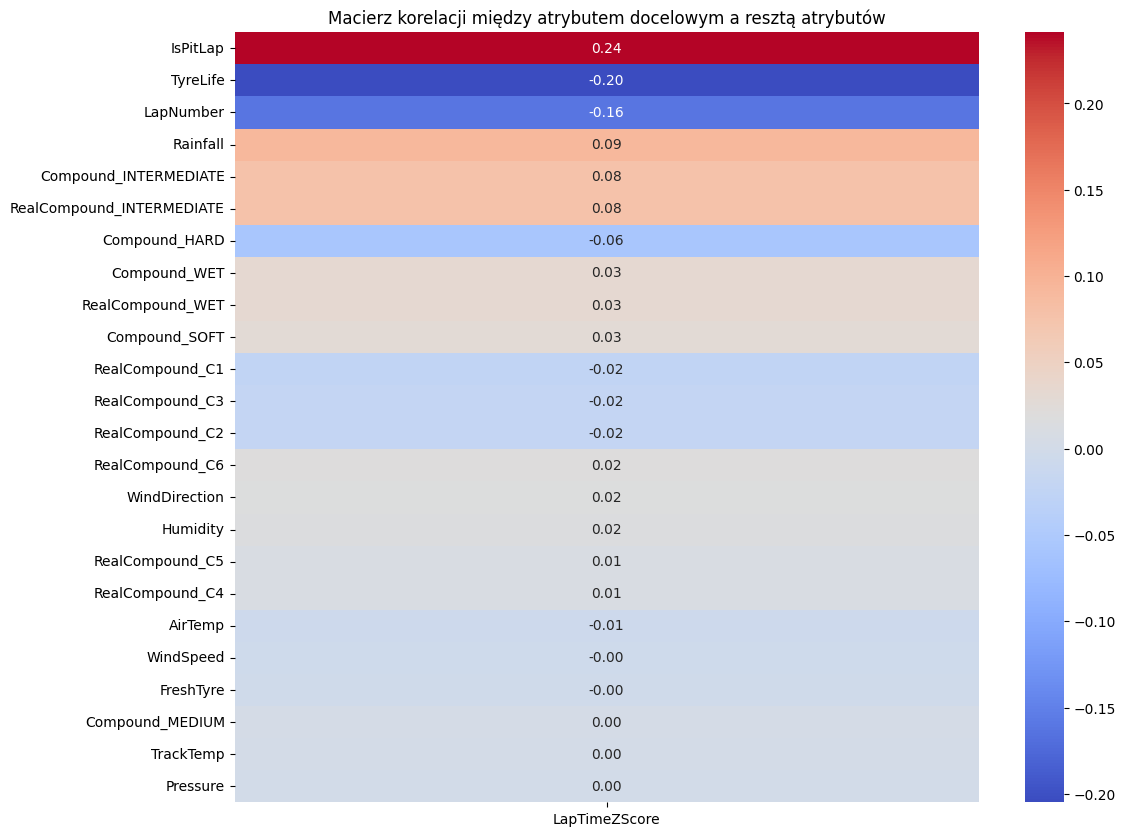

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(corrs), annot=True, fmt=".2f", cmap='coolwarm')

plt.title('Wykres korelacji między atrybutem docelowym a resztą atrybutów')
plt.show()